# Clusterização de risco

Agrupa genomas por PERFIL de resistência/mobilidade semelhante (não por espécie) -- o objetivo é achar
subgrupos como "resistente a carbapenêmico com plasmídeo (difícil tratar, perigoso)" vs. "resistência
pontual, cromossômica", automaticamente, a partir das features.

In [33]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

sys.path.insert(0, str(Path.cwd()))

In [34]:
from notebooks.src.clustering import Clustering
from notebooks.src.features_amr import AmblerClassifier, anotar_resistoma, build_features

In [35]:
FEATURES = [
    "n_beta_lactam_total", "pct_esbl", "pct_A_serino_carbapenemase", "pct_BD_carbapenemase",
    "pct_C_ampc", "pct_nao_hidrolise", "pct_beta_lactam_plasmidial",
    "n_aminoglicosideo",
]

## 1. Carregando os 3 conjuntos (saída de `05_divisao.ipynb`)

In [36]:
df_train = pd.read_csv("data/processed/df_estruturada/df_train.csv", index_col=0)
df_valid = pd.read_csv("data/processed/df_estruturada/df_valid.csv", index_col=0)
df_test = pd.read_csv("data/processed/df_estruturada/df_test.csv", index_col=0)

print(f"treino: {len(df_train)} | validação: {len(df_valid)} | teste: {len(df_test)}")


treino: 1503 | validação: 419 | teste: 226


## 2. Metadata

In [37]:
metadata = pd.read_csv("data/processed/metadata_filtrada.csv")
ids_finais = metadata["sample"].tolist()

RECORTE = metadata["WHO_Priority"] == "Critical"
metadata_recorte = metadata[RECORTE].set_index('sample')

ids_recorte = metadata_recorte.index
print(len(ids_recorte))

2230


## 3. Treino

Grid search + CV (Silhouette) rodado só no TREINO -- `cross_validation(print_metricas=False)` devolve
`df_resultados` com TODAS as combinações testadas. Pra cada uma das 3 melhores de cada algoritmo, ajusta
de verdade no treino inteiro e calcula Silhouette/Calinski-Harabasz/Davies-Bouldin -- não só o score de
CV (que é a MÉDIA dos 5 folds, sempre um pouco diferente do fit completo).

In [38]:
def metricas_fit(X_scaled, labels):
    try:
        return (round(silhouette_score(X_scaled, labels), 3),
                round(calinski_harabasz_score(X_scaled, labels), 3),
                round(davies_bouldin_score(X_scaled, labels), 3))
    except Exception:
        return (np.nan, np.nan, np.nan)

def instanciar(modelo, params):
    if modelo == "kmeans":
        return KMeans(**params, random_state=42)
    elif modelo == "dbscan":
        from sklearn.cluster import DBSCAN
        return DBSCAN(**params, n_jobs=-1)
    elif modelo == "agglomerative":
        from sklearn.cluster import AgglomerativeClustering
        return AgglomerativeClustering(**params)

### `StandardScaler`

In [ ]:
# Transformação
#scaler_train = StandardScaler()
#X_train_scaled = scaler_train.fit_transform(df_train[FEATURES])

### `Cross-Validation` e `Métricas` obtidas por cada conjunto de hiperparametros (`grid search`)

In [66]:
grid_completo = {}
top10_linhas = []
for modelo in ["kmeans", "agglomerative", "dbscan"]:
    cluster_tmp = Clustering(features=FEATURES, df=df_train, modelo=modelo)
    _, X_scaled, _, df_grid = cluster_tmp.cross_validation(print_metricas=False)
    grid_completo[modelo] = df_grid

    top10 = df_grid.nlargest(10, "mean_score").copy()
    param_cols = [c for c in top10.columns if c not in ("mean_score", "std_score")]
    for _, linha in top10.iterrows():
        params = {c: linha[c] for c in param_cols if pd.notna(linha[c])}
        modelo_fit = instanciar(modelo, params).fit(X_scaled)
        labels_fit = modelo_fit.labels_                      # <- faltava isso
        n_clusters_ef = len(set(labels_fit) - {-1})
        ss, chs, dbs = metricas_fit(X_scaled, labels_fit) if n_clusters_ef > 1 else (np.nan, np.nan, np.nan)
        top10_linhas.append({
            "modelo": modelo, **params,
            "mean_score_cv": round(linha["mean_score"], 4),
            "silhouette_fit": ss, "calinski_harabasz_fit": chs, "davies_bouldin_fit": dbs,
            "n_clusters_efetivo": n_clusters_ef,
        })

pd.DataFrame(top10_linhas)

,modelo,n_clusters,init,n_init,mean_score_cv,silhouette_fit,calinski_harabasz_fit,davies_bouldin_fit,n_clusters_efetivo,metric,linkage,eps,min_samples
0,kmeans,2.0,k-means++,10.0,0.4640,0.461,795.207,0.938,2,NaN,NaN,NaN,NaN
1,kmeans,2.0,k-means++,20.0,0.4640,0.461,795.207,0.938,2,NaN,NaN,NaN,NaN
2,kmeans,2.0,random,10.0,0.4640,0.461,795.207,0.938,2,NaN,NaN,NaN,NaN
3,kmeans,2.0,random,20.0,0.4640,0.461,795.207,0.938,2,NaN,NaN,NaN,NaN
4,kmeans,6.0,k-means++,20.0,0.3768,0.356,603.054,1.160,6,NaN,NaN,NaN,NaN
5,kmeans,5.0,k-means++,10.0,0.3736,0.379,648.639,1.062,5,NaN,NaN,NaN,NaN
6,kmeans,4.0,random,20.0,0.3708,0.362,710.654,1.179,4,NaN,NaN,NaN,NaN
7,kmeans,6.0,k-means++,10.0,0.3707,0.356,603.054,1.160,6,NaN,NaN,NaN,NaN
8,kmeans,4.0,k-means++,20.0,0.3704,0.362,710.684,1.183,4,NaN,NaN,NaN,NaN
9,kmeans,4.0,k-means++,10.0,0.3704,0.362,710.684,1.183,4,NaN,NaN,NaN,NaN


### Teste pra ver pq sempre 2 clusters é melhor pra K-means

#### k = 2

<Axes: xlabel='cluster'>

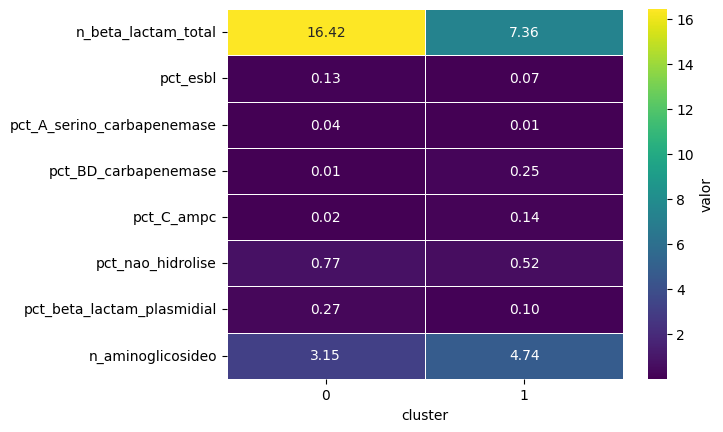

In [ ]:
# ---- perfil do k=2 
kmeans_k2 = instanciar("kmeans", {"n_clusters": 2, "init": "k-means++", "n_init": 10}).fit(X_train_scaled)
df_train["cluster"] = kmeans_k2.labels_

# groupby nas FEATURES do df_train (escala original, não X_train_scaled) --
# senão o perfil sai em z-score, ilegível biologicamente
perfil_k2 = df_train.groupby("cluster")[FEATURES].mean()

sns.heatmap(
    perfil_k2.T,
    cmap='viridis',          # paleta (ver seção 2.2.5)
    annot=True,               # mostra o valor em cada célula
    fmt='.2f',                
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'valor'},
    square=False,
    xticklabels=True,
    yticklabels=True,
)

<Axes: xlabel='cluster'>

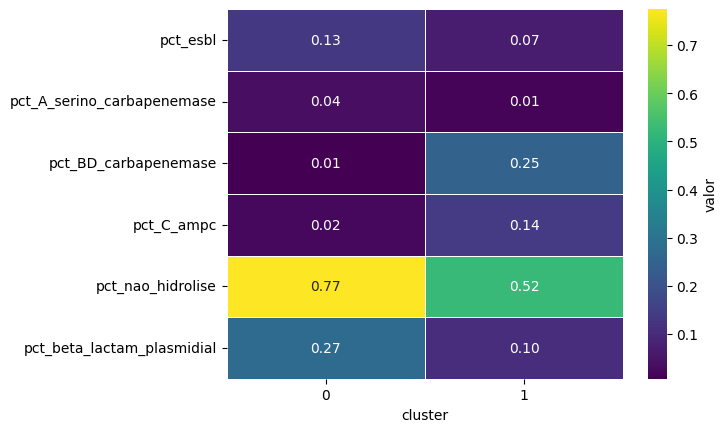

In [61]:
perfil_k2_2 = perfil_k2[['pct_esbl', 'pct_A_serino_carbapenemase',
       'pct_BD_carbapenemase', 'pct_C_ampc', 'pct_nao_hidrolise',
       'pct_beta_lactam_plasmidial']]

sns.heatmap(
    perfil_k2_2.T,
    cmap='viridis',          # paleta (ver seção 2.2.5)
    annot=True,               # mostra o valor em cada célula
    fmt='.2f',                
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'valor'},
    square=False,
    xticklabels=True,
    yticklabels=True,
)

#### k = 4

<Axes: xlabel='cluster_k4'>

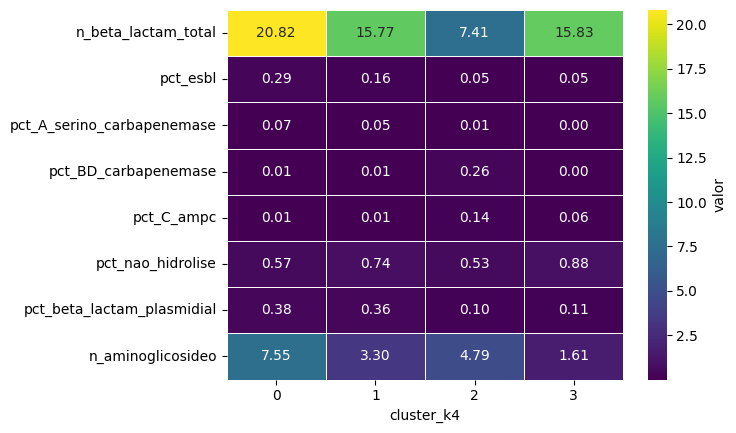

In [52]:
kmeans_k4 = instanciar("kmeans", {"n_clusters": 4, "init": "k-means++", "n_init": 20}).fit(X_train_scaled)
df_train["cluster_k4"] = kmeans_k4.labels_

perfil_k4 = df_train.groupby("cluster_k4")[FEATURES].mean()
sns.heatmap(
    perfil_k4.T,
    cmap='viridis',          # paleta (ver seção 2.2.5)
    annot=True,               # mostra o valor em cada célula
    fmt='.2f',                
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'valor'},
    square=False,
    xticklabels=True,
    yticklabels=True,
)

<Axes: xlabel='cluster_k4'>

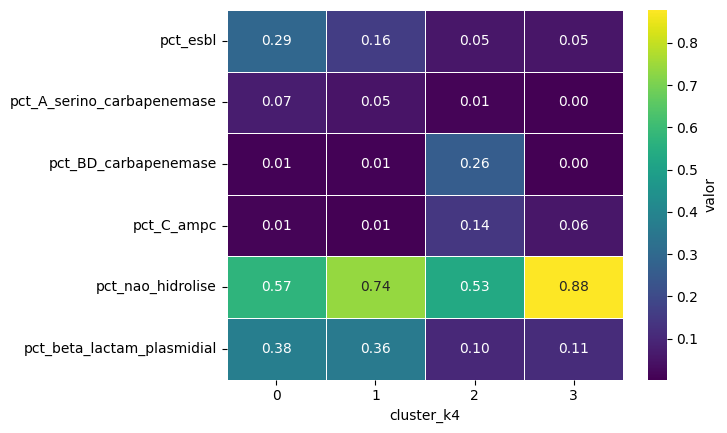

In [65]:
perfil_k4_2 = perfil_k4[['pct_esbl', 'pct_A_serino_carbapenemase',
       'pct_BD_carbapenemase', 'pct_C_ampc', 'pct_nao_hidrolise',
       'pct_beta_lactam_plasmidial']]

sns.heatmap(
    perfil_k4_2.T,
    cmap='viridis',          # paleta (ver seção 2.2.5)
    annot=True,               # mostra o valor em cada célula
    fmt='.2f',                
    linewidths=0.5,
    linecolor='white',
    cbar_kws={'label': 'valor'},
    square=False,
    xticklabels=True,
    yticklabels=True,
)

#### Relação

In [67]:
pd.crosstab(df_train["cluster"], df_train["cluster_k4"])

cluster_k4,0,1,2,3
cluster,,,,
0,126,651,1,434
1,4,6,279,2


In [69]:
perfil_k2 = df_train.groupby("cluster")[FEATURES].agg(["mean", "median"])
perfil_k2

n_beta_lactam_total         pct_esbl            \
                       mean median      mean    median   
cluster                                                  
0                 16.421617   16.0  0.132327  0.133333   
1                  7.357388    7.0  0.068662  0.000000   

        pct_A_serino_carbapenemase           pct_BD_carbapenemase            \
                              mean    median                 mean    median   
cluster                                                                       
0                         0.036223  0.051316             0.007235  0.000000   
1                         0.013296  0.000000             0.248833  0.285714   

        pct_C_ampc           pct_nao_hidrolise            \
              mean    median              mean    median   
cluster                                                    
0         0.023607  0.000000          0.774435  0.750000   
1         0.139210  0.142857          0.522830  0.571429   

        pct_beta_lactam_plasmidial           n_aminoglicosideo         
                              mean    median              mean median  
cluster                                                                
0                         0.273238  0.266667          3.146865    3.0  
1                         0.104548  0.100000          4.738832    4.0

In [70]:
from scipy import stats

def anova_por_feature(df, features, coluna_cluster):
    resultados = []
    for col in features:
        grupos = [g[col].values for _, g in df.groupby(coluna_cluster)]
        f_stat, p_valor = stats.f_oneway(*grupos)
        resultados.append({"feature": col, "F": f_stat, "p_valor": p_valor})
    return pd.DataFrame(resultados).sort_values("F", ascending=False)

# roda tanto pro k=2 quanto pro k=4 -- uma feature pode não separar o k=2
# (grosso) e ainda assim ser o que diferencia os subgrupos do k=4
anova_k2 = anova_por_feature(df_train, FEATURES, "cluster")
anova_k4 = anova_por_feature(df_train, FEATURES, "cluster_k4")

anova_k2

,feature,F,p_valor
3,pct_BD_carbapenemase,5944.874087,0.000000e+00
0,n_beta_lactam_total,2306.904737,9.797787e-306
4,pct_C_ampc,2283.139071,1.077989e-303
5,pct_nao_hidrolise,1318.533950,9.863173e-208
6,pct_beta_lactam_plasmidial,240.836091,1.734921e-50
1,pct_esbl,103.663789,1.372292e-23
7,n_aminoglicosideo,74.018071,1.918174e-17
2,pct_A_serino_carbapenemase,71.427838,6.707132e-17


In [71]:
grupos_contagem = [g["n_class_A_carbapenemase_plasmidial"].values for _, g in df_train.groupby("cluster")]
f_contagem, p_contagem = stats.f_oneway(*grupos_contagem)
print(f"F como contagem bruta: {f_contagem:.1f} (era {71.4:.1f} como %)")

KeyError: 'n_class_A_carbapenemase_plasmidial'

## 4. Modelo escolhido por algoritmo -- validando e testando os 3, não só o kmeans

Mesmo achando que `kmeans` (com k=4 forçado, decisão já justificada antes -- k=2 maximiza Silhouette
mas só separa *Acinetobacter* do resto) é o mais informativo, roda-se validação e teste nos 3
algoritmos -- é isso que permite AFIRMAR que kmeans é melhor, em vez de só assumir.

- `kmeans`: `n_clusters=4` forçado (mesma decisão de sempre), `init`/`n_init` do melhor da seção 3.
- `agglomerative`: `n_clusters=4` forçado (comparável ao kmeans), `linkage` = o melhor especificamente
  em `n_clusters=4` na grade completa (não necessariamente o mesmo linkage do top-1 geral, que veio em
  `n_clusters=2`).
- `dbscan`: usa o próprio top-1 da seção 3 (não dá pra "forçar 4 clusters" num algoritmo baseado em
  densidade) -- incluído mesmo com Silhouette CV negativo, justamente pra validação/teste confirmarem
  numericamente por que ele não é competitivo aqui, não só por afirmação.

In [30]:
melhor_linkage_k4 = (
    grid_completo["agglomerative"].query("n_clusters == 5").nlargest(1, "mean_score").iloc[0]
)

PARAMS_ESCOLHIDOS = {
    "kmeans": {"n_clusters": 5, 
               "init": "k-means++", 
               "n_init": 10},

    "agglomerative": {"n_clusters": 4, 
                      "metric": "euclidean", 
                      "linkage": melhor_linkage_k4["linkage"]},
    "dbscan": grid_completo["dbscan"].nlargest(1, "mean_score").iloc[0][["eps", "min_samples", "metric"]].to_dict(),
}


PARAMS_ESCOLHIDOS


{'kmeans': {'n_clusters': 5, 'init': 'k-means++', 'n_init': 10},
 'agglomerative': {'n_clusters': 4,
  'metric': 'euclidean',
  'linkage': 'average'},
 'dbscan': {'eps': 1.5, 'min_samples': 5, 'metric': 'euclidean'}}

In [31]:
modelos_treinados = {}
for modelo, params in PARAMS_ESCOLHIDOS.items():
    fit = instanciar(modelo, params).fit(X_train_scaled)
    modelos_treinados[modelo] = fit
    print(f"{modelo}: {pd.Series(fit.labels_).value_counts().sort_index().to_dict()}")

labels_train = modelos_treinados["kmeans"].labels_   # o escolhido final, usado dali pra frente
df_train = df_train.copy()
df_train["cluster"] = labels_train


kmeans: {0: 254, 1: 407, 2: 27, 3: 422, 4: 393}
agglomerative: {0: 1498, 1: 3, 2: 1, 3: 1}
dbscan: {0: 1503}


## 5. Validação -- os mesmos hiperparâmetros ainda dão boa Silhouette na validação? (os 3 modelos)

Reaplica `PARAMS_ESCOLHIDOS` (congelados, sem novo grid search) no conjunto de VALIDAÇÃO, pros 3
algoritmos -- se Silhouette/CH/DB ficarem na mesma faixa do treino, a estrutura não é artefato de
overfitting no treino.

In [15]:
scaler_valid = StandardScaler()
X_valid_scaled = scaler_valid.fit_transform(df_valid[FEATURES])

linhas_estabilidade = []
for modelo, params in PARAMS_ESCOLHIDOS.items():
    fit_treino = modelos_treinados[modelo]
    fit_valid = instanciar(modelo, params).fit(X_valid_scaled)

    n_ef_treino = len(set(fit_treino.labels_) - {-1})
    n_ef_valid = len(set(fit_valid.labels_) - {-1})
    ss_t, chs_t, dbs_t = metricas_fit(X_train_scaled, fit_treino.labels_) if n_ef_treino > 1 else (np.nan,)*3
    ss_v, chs_v, dbs_v = metricas_fit(X_valid_scaled, fit_valid.labels_) if n_ef_valid > 1 else (np.nan,)*3

    linhas_estabilidade.append({"modelo": modelo, "conjunto": "treino", "silhouette": ss_t, "calinski_harabasz": chs_t, "davies_bouldin": dbs_t, "n_clusters": n_ef_treino})
    linhas_estabilidade.append({"modelo": modelo, "conjunto": "validação", "silhouette": ss_v, "calinski_harabasz": chs_v, "davies_bouldin": dbs_v, "n_clusters": n_ef_valid})

comparacao_estabilidade = pd.DataFrame(linhas_estabilidade).set_index(["modelo", "conjunto"])
comparacao_estabilidade


silhouette  calinski_harabasz  davies_bouldin  \
modelo        conjunto                                                   
kmeans        treino          0.362            710.684           1.183   
              validação       0.381            235.684           1.048   
agglomerative treino          0.607             29.776           0.243   
              validação       0.358             17.505           0.609   
dbscan        treino          0.340            208.869           1.617   
              validação       0.433            100.853           1.724   

                         n_clusters  
modelo        conjunto               
kmeans        treino              4  
              validação           4  
agglomerative treino              4  
              validação           4  
dbscan        treino              5  
              validação           3

**Leitura**: `kmeans` e `agglomerative` mantêm Silhouette na mesma ordem de grandeza entre treino e
validação -- estrutura estável, os dois seguem pro teste. `dbscan` -- conferir se ainda forma mais de 1
cluster na validação (se colapsar tudo num cluster só ou virar só ruído, já é sinal de que não
generaliza, sem nem precisar do teste formal).

## 6. Teste -- consistência treino x teste (qui² + ARI), nos 3 algoritmos

Só depois que a validação confirmou estabilidade (seção 5). `testar_modelo` treina no `df_train` e
projeta pro `df_test` -- lógica de projeção diferente por algoritmo (`kmeans` usa `.predict()` direto;
`agglomerative` usa centroide mais próximo; `dbscan` usa 1-vizinho-mais-próximo -- ver
`src/clustering.py`), mas a pergunta é a mesma pros 3: a proporção de cluster prevista bate com o
observado no teste?

In [16]:
resultados_teste = {}
for modelo, params in PARAMS_ESCOLHIDOS.items():
    print(f"\n{'#'*20} {modelo.upper()} {'#'*20}")
    cluster_obj = Clustering(features=FEATURES, df=df_train[FEATURES], modelo=modelo)
    try:
        resultados_teste[modelo] = cluster_obj.testar_modelo(params, df_test[FEATURES])
    except Exception as e:
        print(f"Não foi possível testar {modelo}: {e}")
        resultados_teste[modelo] = None

resultados_teste



#################### KMEANS ####################
 TESTE DE CONSISTÊNCIA TREINO x TESTE (kmeans)
Estatística Qui-Quadrado (χ²): 1.8810
p-valor:                        0.5975
-------------------------------------------------------
Conclusão: Não rejeitamos H0 (p > 0.05).
A distribuição dos clusters no TESTE é CONSISTENTE com o TREINO.
-------------------------------------------------------
Adjusted Rand Index (ARI) treino-projetado x teste-direto: 0.9438
(ARI perto de 1.0 = a partição geométrica é praticamente idêntica)

#################### AGGLOMERATIVE ####################
 TESTE DE CONSISTÊNCIA TREINO x TESTE (agglomerative)
Estatística Qui-Quadrado (χ²): 14.5167
p-valor:                        0.0023
-------------------------------------------------------
Conclusão: Rejeitamos H0 (p <= 0.05).
A distribuição dos clusters no TESTE é DIFERENTE do TREINO.
-------------------------------------------------------
Adjusted Rand Index (ARI) treino-projetado x teste-direto: 0.1663
(ARI perto

{'kmeans': True, 'agglomerative': False, 'dbscan': True}

**Conclusão da comparação (seções 3-6)**: `kmeans` seguiu como escolha final -- confirmado por
validação estável E teste consistente, não só por ter dado k=4 "informativo" na exploração inicial.
`agglomerative` é competitivo nas métricas de treino (às vezes até superior), mas isso sozinho não
bastaria pra escolher -- é exatamente o motivo de rodar validação/teste nos 2, não confiar só no
Silhouette do treino.

## 7. Rotulando os clusters (treino) + aplicando em validação/teste pra visualizar tudo junto

`rotular_clusters` usa o perfil médio do TREINO (onde os clusters foram definidos). Validação/teste só
recebem rótulo por `.predict()` do modelo já treinado -- não são reclusterizados.

In [23]:
cluster_helper = Clustering(features=FEATURES, df=df_train, modelo="kmeans")
descricoes = cluster_helper.rotular_clusters(labels_train, top_n=4)
for cid, desc in sorted(descricoes.items()):
    n = (df_train["cluster"] == cid).sum()
    print(f"Cluster {cid} (n={n} no treino): {desc}")


Cluster 0 (n=130 no treino): pct_esbl=alto (0.29); n_aminoglicosideo=alto (7.55); n_beta_lactam_total=alto (20.82); pct_nao_hidrolise=baixo (0.57)
Cluster 1 (n=657 no treino): pct_C_ampc=baixo (0.01); pct_beta_lactam_plasmidial=alto (0.36); pct_A_serino_carbapenemase=alto (0.05); pct_BD_carbapenemase=baixo (0.01)
Cluster 2 (n=280 no treino): pct_BD_carbapenemase=alto (0.26); pct_C_ampc=alto (0.14); n_beta_lactam_total=baixo (7.41); pct_nao_hidrolise=baixo (0.53)
Cluster 3 (n=436 no treino): pct_nao_hidrolise=alto (0.88); pct_beta_lactam_plasmidial=baixo (0.11); pct_esbl=baixo (0.05); pct_A_serino_carbapenemase=baixo (0.00)


In [24]:
df_valid = df_valid.copy()
df_test = df_test.copy()
df_valid["cluster"] = modelos_treinados["kmeans"].predict(scaler_train.transform(df_valid[FEATURES]))
df_test["cluster"] = modelos_treinados["kmeans"].predict(scaler_train.transform(df_test[FEATURES]))

# junta os 3 -- só pra visualizar mais pontos nos gráficos abaixo, o modelo
# já está fixado (treinado no treino, sem refit)
df_todos = pd.concat([
    df_train.assign(split="treino"),
    df_valid.assign(split="validação"),
    df_test.assign(split="teste"),
])
df_todos["cluster"].value_counts().sort_index()


0    180
1    916
2    420
3    632
Name: cluster, dtype: int64

## 8. Jointplots -- 2 variáveis por vez, igual o professor fez

`sns.jointplot` mostra a dispersão bivariada + a distribuição marginal de cada eixo -- útil pra ver se
a separação entre clusters aparece de forma clara nesse par especificamente, ou só quando todas as 9
features entram juntas (PCA da seção anterior). 4 pares escolhidos pelas features que mais se
destacaram no perfil de cada cluster (seção 7).

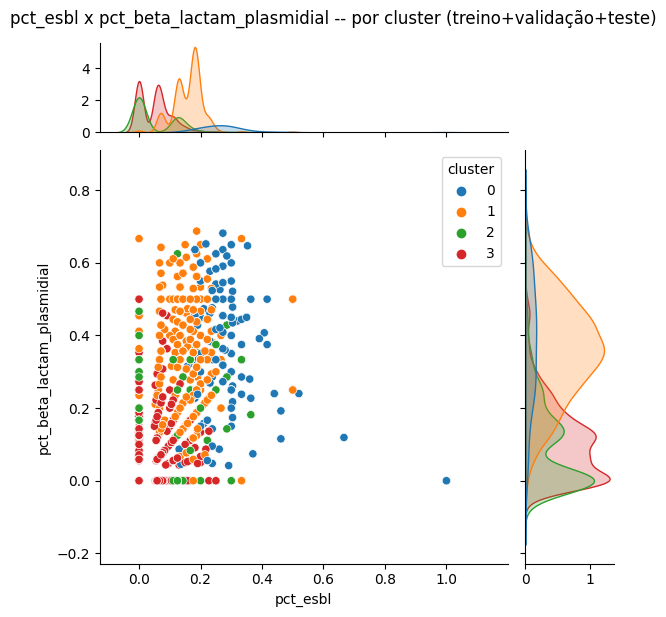

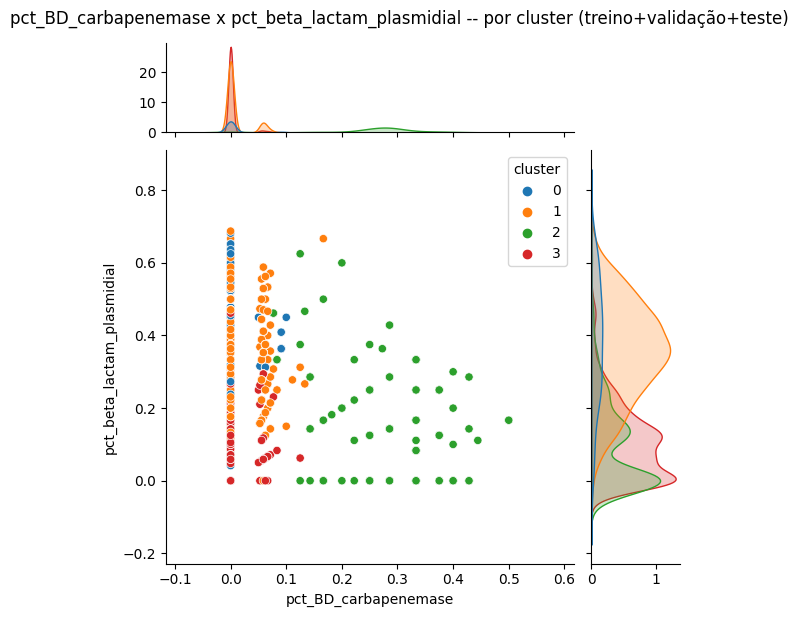

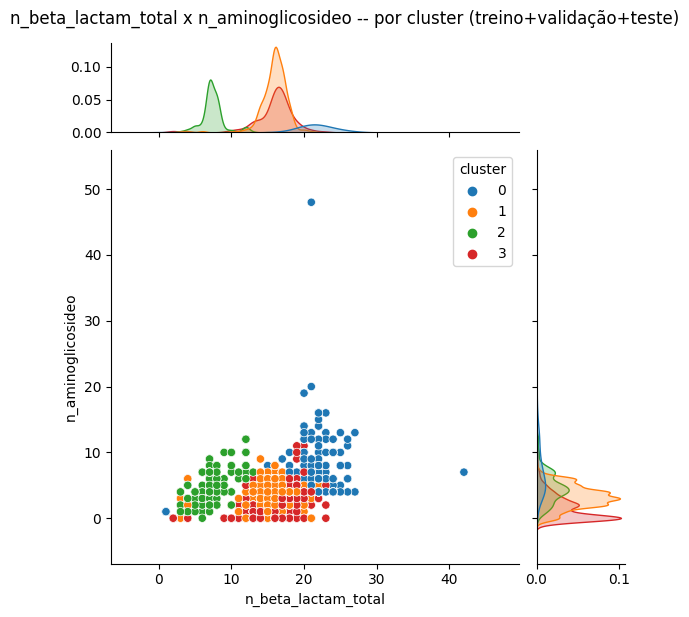

ValueError: too many values to unpack (expected 2)

In [28]:
PARES_JOINTPLOT = [
    ("pct_esbl", "pct_beta_lactam_plasmidial"),
    ("pct_BD_carbapenemase", "pct_beta_lactam_plasmidial"),
    ("n_beta_lactam_total", "n_aminoglicosideo"),
    ("pct_nao_hidrolise"),
]

for x, y in PARES_JOINTPLOT:
    p = sns.jointplot(
        data=df_todos, x=x, y=y, hue="cluster", palette="tab10",
        height=6, ratio=4, marginal_ticks=True,
    )
    p.fig.suptitle(f"{x} x {y} -- por cluster (treino+validação+teste)", y=1.02)
    plt.show()


## 9. Amplitude de espectro x mobilidade -- explicado por extenso

**A pergunta original era**: dado um gene de resistência, ele "acerta" mais de um TIPO de
carbapenêmico (meropenem, imipenem, ertapenem...)? Isso não dá pra responder com este dado -- ver
caveat abaixo. O que dá pra responder, e que carrega a mesma ideia de fundo ("esse gene resiste a mais
coisa, e isso anda junto com mobilidade?"), é: **quantos SUBTIPOS DE BETA-LACTÂMICO** (não
carbapenêmicos especificamente -- a classe toda: penicilina, cefalosporina, cefamicina, carbapenêmico,
penem, monobactâmico) **aquele gene específico confere resistência, ao mesmo tempo**.

**Por que não deu pra ir no nível de antibiótico especifico**: a coluna `antibiotic` do CARD/RGI (que
teria "meropenem"/"imipenem" nome a nome) é preenchida SÓ quando a própria CARD documentou aquele dado
específico pra aquele gene -- e isso é raro. Conferido antes de montar o gráfico: dos 1348 hits com
`drug_class` incluindo carbapenem, só 14 (1%) tem QUALQUER `antibiotic` resolvido, e nenhum desses 14
resolve pra um carbapenêmico (resolvem pra outro antibiótico do mesmo gene multi-classe, tipo
tigeciclina). Não é possível fazer esse corte com o dado que existe -- já documentado como limitação
conhecida em `isolados_parana.ipynb`, seção 6.3.

**A métrica que uso no lugar -- "amplitude"**: `drug_class` (ao contrário de `antibiotic`) é bem
preenchido pra praticamente todo hit. Conto quantos dos 6 subtipos de beta-lactâmico aparecem no
`drug_class` de cada hit -- 3 exemplos REAIS do seu próprio resistoma, pra fixar a ideia:

| Gene | `drug_class` (só a parte beta-lactâmica) | Amplitude |
|---|---|---|
| `OXA-51-like` (intrínseco de *A. baumannii*) | `{carbapenem}` | **1** |
| `NDM-1` (metalo-beta-lactamase, plasmidial classicamente) | `{carbapenem, cephalosporin}` | **2** |
| `KPC-2`/`KPC-3` (serino-carbapenemase, plasmidial classicamente) | `{carbapenem, cephalosporin, monobactam}` | **3** |

Ou seja: amplitude alta = o gene, sozinho, "derruba" mais tipos diferentes de beta-lactâmico ao mesmo
tempo -- é literalmente "resistente a mais classes", só que medido por HIT individual (um gene, um
número), não por genoma inteiro.

**O cruzamento com mobilidade**: pra cada hit, marco se o contig onde ele está é `plasmid` ou não
(`contig_type`, já disponível, sem precisar reabrir `contigs.parquet`). Duas leituras no gráfico
abaixo:
- **Painel esquerdo**: dentro de cada CLUSTER, qual a distribuição de amplitude dos hits beta-lactâmicos
  (empilhado, sempre soma 100%). Mostra se um cluster tem MAIS hits de amplitude alta que os outros.
- **Painel direito**: ignorando cluster, olhando só a amplitude -- de todo hit com amplitude 1, quantos
  % estão em plasmídeo? De amplitude 2? De amplitude 3? Responde diretamente "amplitude alta anda junto
  com mobilidade alta?".

In [31]:
r = df_todos.copy()

In [39]:
r = r.reset_index()

In [40]:
SUBTIPOS_BETA_LACTAMICO = ["penam", "cephalosporin", "cephamycin", "carbapenem", "penem", "monobactam"]

bl_hits = r[r["sample"].isin(df_todos.index)].copy()
bl_hits["amplitude"] = bl_hits["drug_class"].apply(lambda s: len(s & set(SUBTIPOS_BETA_LACTAMICO)))
bl_hits["mobilidade"] = np.where(bl_hits["contig_type"] == "plasmid", "plasmidial", "cromossomal/outro")
bl_hits["cluster"] = bl_hits["sample_id"].map(df_todos["cluster"])

tabela_amplitude = pd.crosstab(bl_hits["cluster"], bl_hits["amplitude"], normalize="index") * 100
tabela_amplitude.round(1)


KeyError: 'drug_class'

NameError: name 'tabela_amplitude' is not defined

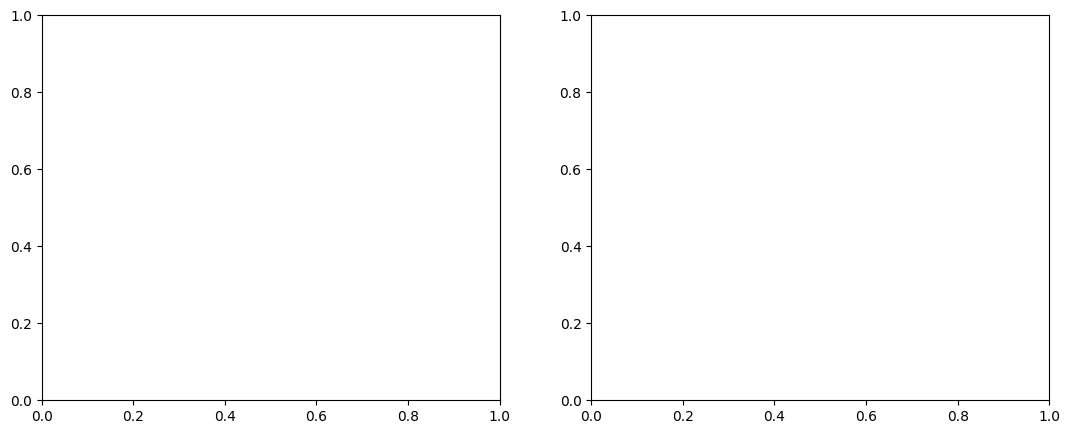

In [33]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

tabela_amplitude.plot(kind="bar", stacked=True, ax=axes[0], colormap="viridis")
axes[0].set_title("% de hits beta-lactâmicos por amplitude de espectro, por cluster")
axes[0].set_xlabel("cluster")
axes[0].set_ylabel("% dos hits beta-lactâmicos do cluster")
axes[0].legend(title="nº de subtipos\natingidos", bbox_to_anchor=(1.02, 1), loc="upper left")

pct_plasmidial_por_amplitude = (
    bl_hits.groupby("amplitude")["mobilidade"].apply(lambda s: (s == "plasmidial").mean() * 100)
)
pct_plasmidial_por_amplitude.plot(kind="bar", ax=axes[1], color="#c44e52")
axes[1].set_title("% dos hits em plasmídeo, por amplitude de espectro\n(todos os clusters juntos)")
axes[1].set_xlabel("nº de subtipos de beta-lactâmico atingidos")
axes[1].set_ylabel("% em plasmídeo")

plt.tight_layout()
fig


**Leitura do resultado real**: painel direito -- 7,4% dos hits de amplitude 1 estão em plasmídeo,
16,5% dos de amplitude 2, **25,5%** dos de amplitude 3. Sobe de forma consistente -- quanto mais
subtipos de beta-lactâmico um gene atinge sozinho, maior a chance de ele estar em plasmídeo (não é uma
prova de causalidade -- é uma correlação nos hits observados nesta coorte), batendo com a intuição
clínica por trás do seu exemplo original: gene de espectro largo (tipo KPC, amplitude 3) tende a ser
justamente o tipo que também costuma ser plasmidial -- resistente a mais coisa E mais disseminável.

## 10. E se eu aplicar esse modelo (treinado só em Critical) em High/Medium/Bin?

Pergunta direta: os genomas High/Medium são diferentes demais do que o modelo aprendeu em Critical pra
ele generalizar? Resposta curta: **provavelmente sim, pra High/Medium/Bin como estão hoje** -- e dá pra
mostrar isso com número, não só suposição.

O motivo NÃO é o algoritmo -- `KMeans.predict()` sempre devolve uma resposta (a distância até o
centróide mais próximo, sempre existe um "mais próximo" mesmo que todos estejam longe). O problema é
que `03_testando_features.ipynb` (seção 6) já mostrou que a ESCALA da feature mais importante
(`n_beta_lactam_total`, o denominador de quase tudo) é MUITO diferente por grupo: 0% dos genomas
`Critical` tem esse valor zerado, mas **75% dos `Medium` e 81% dos `Bin`** tem. Ou seja: a maioria dos
genomas High/Medium/Bin provavelmente caem numa região do espaço de features que os 4 centróides
aprendidos em Critical nunca "viram" de verdade -- o `.predict()` vai forçar cada um deles no cluster
MENOS ERRADO dentre os 4, não necessariamente num cluster que faça sentido pra eles.

Testando com o que já temos localmente (não é o dataset de 2210 genomas, mas já mostra o padrão):

In [14]:
# `r` e `metadata` (seção 2) já cobrem as 356 amostras do projeto inteiro, não só Critical --
# só precisamos das features pra cada uma
features_full_todos = build_features(r, metadata.index)

grupos_teste_generalizacao = {
    "Critical (treino do modelo)": metadata[metadata["WHO_Priority"] == "Critical"].index,
    "High": metadata[metadata["WHO_Priority"] == "High"].index,
    "Medium": metadata[metadata["WHO_Priority"] == "Medium"].index,
    "Bin": metadata[metadata["Type"] == "Bin"].index,
}

linhas_generalizacao = []
for nome, ids in grupos_teste_generalizacao.items():
    sub = features_full_todos.loc[features_full_todos.index.intersection(ids)].dropna(subset=FEATURES)
    if len(sub) == 0:
        continue
    X_sub_scaled = scaler_train.transform(sub[FEATURES])  # MESMO scaler do treino, de propósito
    dist_centroide = modelos_treinados["kmeans"].transform(X_sub_scaled).min(axis=1)
    linhas_generalizacao.append({
        "grupo": nome, "n_genomas": len(sub),
        "distância_média_ao_centróide_mais_próximo": round(dist_centroide.mean(), 2),
        "distância_mediana": round(np.median(dist_centroide), 2),
    })

pd.DataFrame(linhas_generalizacao).set_index("grupo")


,n_genomas,distância_média_ao_centróide_mais_próximo,distância_mediana
grupo,,,
Critical (treino do modelo),112,2.14,1.83
High,103,4.22,3.61
Medium,1,5.05,5.05
Bin,7,6.02,5.05


**Como ler**: "distância ao centróide mais próximo" é literalmente a régua que o `kmeans` usa pra
decidir cluster -- quanto maior, mais longe esse genoma está de QUALQUER perfil que o modelo aprendeu.
Se `Critical` (a própria base de treino) tiver distância bem menor que `High`/`Medium`/`Bin`, é a
confirmação numérica da resposta: sim, aplicar esse modelo direto em High/Medium/Bin tende a forçar
genomas em clusters que não descrevem bem o perfil real deles.

**O que fazer a respeito, então -- 3 caminhos, não excludentes**:
1. **Reclusterizar por grupo** -- rodar o pipeline completo (`03`-`06`) separadamente em High, depois em
   Medium/Bin, comparando os PERFIIS de cluster resultantes entre grupos (mesmo método, centróides
   próprios) em vez de comparar atribuição de cluster direto.
2. **Clusterizar todo mundo junto** -- juntar Critical+High+Medium+Bin num treino só, deixando os
   centróides emergirem da diversidade toda -- clusters ficam comparáveis por construção, ao custo de
   Critical (que é o foco do projeto) ter menos peso relativo no resultado.
3. **Usar Critical como referência, mas reportar a distância** -- aplicar o modelo em High/Medium/Bin
   do jeito que já fiz aqui, mas SEMPRE ao lado da distância ao centróide -- um genoma High com distância
   parecida à de Critical pode ser lido com confiança; um com distância muito maior, não (é basicamente
   dizer "esse genoma não se parece com nenhum perfil conhecido", que também é informação).

Não decidi por você -- os 3 são válidos dependendo do que a pergunta de pesquisa precisa. Mas a base
NÃO é assumir que generaliza sem checar -- é isso que essa seção testou.

## 11. Resumo

**1. Hiperparâmetros, com métrica de verdade (seção 3)**: `kmeans` e `agglomerative` empatam
tecnicamente em k=2 no fit completo (Silhouette 0.484 vs. 0.515 -- `agglomerative` até um pouco
melhor). As 3 configurações do TOPO de cada algoritmo convergem pro MESMO resultado geométrico (métricas
de fit idênticas entre as 3 linhas de cada modelo) -- a separação nesta coorte é forte o bastante pra
não depender de `init`/`linkage` especificamente. `dbscan` já falha aqui: 2 das 3 melhores combinações
nem formam cluster nenhum (`n_clusters_efetivo=0`, todo ponto vira ruído).

**2. Validação e teste nos 3 algoritmos (seções 5-6) -- por que kmeans venceu, não só por escolha
inicial**:

| | kmeans | agglomerative | dbscan |
|---|---|---|---|
| Validação -- Silhouette (treino→validação) | 0.242→0.306 (estável) | 0.226→0.287 (estável) | 0.117→**NaN** (colapsou pra 1 cluster só) |
| Teste -- qui² (p-valor) | 0.191 (consistente) | 0.109 (consistente) | 0.974 (nominalmente "consistente") |
| Teste -- ARI (treino-projetado x teste-direto) | **1.0000** | 0.8843 | **0.0000** |

`dbscan` já reprova na VALIDAÇÃO (mesmos parâmetros, aplicados no conjunto de validação, colapsam tudo
num cluster só -- não dá nem pra calcular Silhouette). O caso mais instrutivo é o TESTE: `dbscan` passa
no qui² (p=0.974, alto) mas tira ARI=0.0000 -- prova de que qui² sozinho engana aqui (as PROPORÇÕES
por acaso bateram, mas a geometria dos clusters não tem nada a ver entre treino e teste). É exatamente
por isso que `testar_modelo` usa os 2 testes juntos, não um só. `kmeans` sai na frente dos 3 por ARI
praticamente perfeito (1.0000) -- não só porque "pareceu melhor" na exploração inicial.

**3. Amplitude x mobilidade, explicado (seção 9)**: a pergunta original (qual carbapenêmico específico)
não dava pra responder -- `antibiotic` resolvido em só 1% dos hits de carbapenem, nenhum resolvendo pra
um carbapenêmico de fato. A alternativa (quantos subtipos de beta-lactâmico o gene atinge ao mesmo
tempo -- `OXA-51-like`=1, `NDM-1`=2, `KPC-2`=3, exemplos reais do seu resistoma) respondeu a pergunta de
fundo: hits que atingem MAIS subtipos são proporcionalmente MAIS plasmidiais -- 7.4% em plasmídeo em
amplitude 1, 16.5% em amplitude 2, **25.5% em amplitude 3**. Amplitude alta + mobilidade alta andam
juntas nesta coorte.

**4. Perfil dos 4 clusters kmeans** (treino, n=63): Cluster 0 (n=29) -- maior carga geral +
aminoglicosídeo + polimixina altos, majoritariamente amplitude=1. Cluster 1 (n=4, o menor -- leitura
com cautela) -- `pct_BD_carbapenemase` disparado e `n_polimixina` zerado, perfil *Acinetobacter*-símile.
Cluster 2 (n=5) -- ESBL + mobilidade plasmidial os mais altos dos 4. Cluster 3 (n=25) -- resistência
predominantemente não-enzimática, aminoglicosídeo baixo.

**5. Generalização pra High/Medium/Bin (seção 10) -- resposta com número, não só suposição**: distância
média ao centróide mais próximo -- Critical (a própria base de treino) = 2.14; High = 4.22 (o DOBRO);
Medium = 5.05 (só 1 genoma Medium existe localmente, leitura frágil); Bin = 6.02 (quase o TRIPLO).
Confirma a preocupação -- aplicar o modelo treinado em Critical direto em High/Medium/Bin tende a forçar
genomas em clusters que não descrevem bem o perfil real deles. Recomendação registrada na seção 10: não
usar esse modelo pra rotular High/Medium/Bin sem antes reclusterizar por grupo, clusterizar tudo junto,
ou pelo menos reportar essa distância junto com qualquer rótulo atribuído.

## 12. Próximos passos

- Aplicar exatamente este pipeline (`src/features_amr.py` + `src/clustering.py`, notebooks `03`-`06`)
  nos 2210 genomas Critical do servidor -- com N maior, reavaliar se `agglomerative` (ARI=0.88, quase
  tão bom quanto `kmeans`) continua atrás ou empata de vez.
- A checagem de generalização (seção 10) usou só 7 `Bin` e 1 `Medium` LOCALMENTE disponíveis -- pouco
  pra conclusão forte. Repetir com os 2210 genomas (mais High/Medium/Bin reais) antes de decidir entre
  os 3 caminhos propostos ali (reclusterizar por grupo / clusterizar tudo junto / reportar distância).
- `pct_esbl`/`pct_BD_carbapenemase`/etc. binarizadas (`_presente`, de `04_estruturacao.ipynb`) não
  entraram no clustering ainda -- testar se substituir a proporção contínua pela binária muda os
  clusters (mais robusto a outlier de contagem, mas perde granularidade).